In [170]:
import math
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sys

from mlxtend import __version__ as mlxtend_version
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

from collections import defaultdict
from scipy.stats import pearsonr

DATASET_FOLDER = "dataset/"

In [171]:
artists = pd.read_csv(DATASET_FOLDER + 'artists.csv', sep=';')
tracks = pd.read_csv(DATASET_FOLDER + 'tracks.csv', sep=',')

print(artists.head())


     id_author           name gender  birth_date birth_place nationality  \
0  ART82291002       99 posse      M         NaN         NaN         NaN   
1  ART53496045  achille lauro      M  1990-07-11      Verona      Italia   
2  ART18853907           alfa      M         NaN         NaN         NaN   
3  ART64265460      anna pepe      F         NaN         NaN         NaN   
4  ART75741740    articolo 31      M         NaN         NaN         NaN   

                            description active_start  active_end province  \
0              gruppo musicale italiano   1991-01-01         NaN      NaN   
1  cantautore e rapper italiano (1990-)   2012-01-01         NaN   Verona   
2                                   NaN          NaN         NaN      NaN   
3                                   NaN          NaN         NaN      NaN   
4      gruppo musicale hip hop italiano   1990-01-01         NaN      NaN   

   region country   latitude  longitude  
0     NaN     NaN        NaN        Na

In [172]:
print(tracks.head())

         id    id_artist    name_artist  \
0  TR934808  ART04205421  Rosa Chemical   
1  TR760029  ART04205421  Rosa Chemical   
2  TR916821  ART04205421  Rosa Chemical   
3  TR480968  ART04205421  Rosa Chemical   
4  TR585039  ART04205421  Rosa Chemical   

                                          full_title         title  \
0    ​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè)  ​polka 2 :-/   
1         POLKA by Rosa Chemical (Ft. Thelonious B.)         POLKA   
2  ​britney ;-) by Rosa Chemical (Ft. MamboLosco ...  ​britney ;-)   
3                  CEO by Rosa Chemical (Ft. Taxi B)           CEO   
4                LONDRA by Rosa Chemical (Ft. Rkomi)        LONDRA   

      featured_artists primary_artist language              album  \
0           Ernia, Guè  Rosa Chemical       pl   FOREVER AND EVER   
1        Thelonious B.  Rosa Chemical       en   FOREVER AND EVER   
2  MamboLosco, RADICAL  Rosa Chemical       en   FOREVER AND EVER   
3               Taxi B  Rosa Chemical       

In [173]:
print(len(tracks),
len(artists))

11166 104


In [174]:
artists_p = artists.add_prefix("artist_")
tracks_p = tracks.add_prefix("track_")

merged = tracks_p.merge(
    artists_p,
    how="left",
    left_on="track_id_artist",
    right_on="artist_id_author"
)

track_cols = [c for c in merged.columns if c.startswith("track_")]
artist_cols = [c for c in merged.columns if c.startswith("artist_")]

print(merged.head())


   track_id track_id_artist track_name_artist  \
0  TR934808     ART04205421     Rosa Chemical   
1  TR760029     ART04205421     Rosa Chemical   
2  TR916821     ART04205421     Rosa Chemical   
3  TR480968     ART04205421     Rosa Chemical   
4  TR585039     ART04205421     Rosa Chemical   

                                    track_full_title   track_title  \
0    ​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè)  ​polka 2 :-/   
1         POLKA by Rosa Chemical (Ft. Thelonious B.)         POLKA   
2  ​britney ;-) by Rosa Chemical (Ft. MamboLosco ...  ​britney ;-)   
3                  CEO by Rosa Chemical (Ft. Taxi B)           CEO   
4                LONDRA by Rosa Chemical (Ft. Rkomi)        LONDRA   

  track_featured_artists track_primary_artist track_language  \
0             Ernia, Guè        Rosa Chemical             pl   
1          Thelonious B.        Rosa Chemical             en   
2    MamboLosco, RADICAL        Rosa Chemical             en   
3                 Taxi B    

In [175]:
print(merged.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 11166 entries, 0 to 11165
Data columns (total 59 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   track_id                    11166 non-null  object 
 1   track_id_artist             11166 non-null  object 
 2   track_name_artist           11166 non-null  object 
 3   track_full_title            11166 non-null  object 
 4   track_title                 11166 non-null  object 
 5   track_featured_artists      3517 non-null   object 
 6   track_primary_artist        11166 non-null  object 
 7   track_language              11061 non-null  object 
 8   track_album                 9652 non-null   object 
 9   track_stats_pageviews       4642 non-null   float64
 10  track_swear_IT              11166 non-null  int64  
 11  track_swear_EN              11166 non-null  int64  
 12  track_swear_IT_words        11166 non-null  object 
 13  track_swear_EN_words        111

In [176]:
merged.drop(columns=["artist_active_end"], inplace=True)

In [177]:
for i in merged.columns:
    n= merged[i].isnull().sum()
    print(f"{i}: {n} null")


track_id: 0 null
track_id_artist: 0 null
track_name_artist: 0 null
track_full_title: 0 null
track_title: 0 null
track_featured_artists: 7649 null
track_primary_artist: 0 null
track_language: 105 null
track_album: 1514 null
track_stats_pageviews: 6524 null
track_swear_IT: 0 null
track_swear_EN: 0 null
track_swear_IT_words: 0 null
track_swear_EN_words: 0 null
track_year: 400 null
track_month: 1197 null
track_day: 1323 null
track_n_sentences: 76 null
track_n_tokens: 76 null
track_tokens_per_sent: 76 null
track_char_per_tok: 76 null
track_lexical_density: 76 null
track_avg_token_per_clause: 76 null
track_bpm: 64 null
track_centroid: 64 null
track_rolloff: 64 null
track_flux: 64 null
track_rms: 64 null
track_zcr: 64 null
track_flatness: 64 null
track_spectral_complexity: 64 null
track_pitch: 64 null
track_loudness: 64 null
track_album_name: 78 null
track_album_release_date: 78 null
track_album_type: 78 null
track_disc_number: 78 null
track_track_number: 78 null
track_duration_ms: 78 null
tr

In [178]:
duplicated_tracks= len(merged) - len(merged.track_id.unique())
print('Numero canzoni duplicate:', duplicated_tracks)

Numero canzoni duplicate: 73


In [179]:
dup_ids = merged.loc[merged["track_id"].duplicated(keep=False), "track_id"]
rows_with_same_track_id = merged[merged["track_id"].isin(dup_ids)].sort_values("track_id")
rows_with_same_track_id

c:\Users\ludol\miniconda3\envs\myenv\Lib\site-packages\pandas\core\algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


,track_id,track_id_artist,track_name_artist,track_full_title,track_title,track_featured_artists,track_primary_artist,track_language,track_album,track_stats_pageviews,...,artist_birth_date,artist_birth_place,artist_nationality,artist_description,artist_active_start,artist_province,artist_region,artist_country,artist_latitude,artist_longitude
4240,TR108862,ART56320683,Bassi Maestro,Sushi Bar by Bassi Maestro,Sushi Bar,NaN,Bassi Maestro,en,Sushi EP,NaN,...,1973-08-03,Milano,Italia,"rapper, disc jockey, beatmaker e produttore di...",1988-01-01,Milano,Lombardia,Italia,45.464194,9.189635
7786,TR108862,ART07127070,Noyz Narcos,SPINE by Noyz Narcos (Ft. Coez),SPINE,Coez,Noyz Narcos,cs,VIRUS (Deluxe),19050.0,...,1979-12-15,Roma,Italia,rapper e produttore discografico italiano (1979-),1996-01-01,Roma,Lazio,Italia,41.893320,12.482932
3199,TR135764,ART73965015,Ghemon,Nessuno vale quanto te by Ghemon,Nessuno vale quanto te,NaN,Ghemon,it,ORCHIdee,7182.0,...,1982-04-01,Avellino,Italia,"rapper, cantante e stand up comedian italiano",1996-01-01,Avellino,Campania,Italia,40.996545,15.140569
5847,TR135764,ART86549066,Emis Killa,Giovani eroi by Emis Killa (Ft. Not Good),Giovani eroi,Not Good,Emis Killa,it,"Keta Music, Vol. 3",13155.0,...,1989-11-14,Vimercate,Italia,rapper italiano (1989-),2006-01-01,Monza e della Brianza,Lombardia,Italia,45.613963,9.370060
8104,TR190585,ART78209349,Coez,Nei treni la notte by Coez (Ft. Frah Quintale),Nei treni la notte,Frah Quintale,Coez,it,From The Rooftop 2,NaN,...,1983-07-11,Nocera Inferiore,Italia,cantautore e rapper italiano (1983-),2002-01-01,Salerno,Campania,Italia,40.747213,14.643320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2474,TR980497,ART48537029,Mistaman,Te-le-co-man-do by Mistaman,Te-le-co-man-do,NaN,Mistaman,it,Anni senza fine,NaN,...,1976-09-11,Treviso,Italia,rapper italiano,NaN,Treviso,Veneto,Italia,45.806691,12.206316
4190,TR987615,ART56320683,Bassi Maestro,Django Muzik by Bassi Maestro (Ft. Mondo Marcio),Django Muzik,Mondo Marcio,Bassi Maestro,it,Guarda In Cielo,NaN,...,1973-08-03,Milano,Italia,"rapper, disc jockey, beatmaker e produttore di...",1988-01-01,Milano,Lombardia,Italia,45.464194,9.189635
1318,TR987615,ART63613967,Massimo Pericolo,Polo Nord by Massimo Pericolo,Polo Nord,NaN,Massimo Pericolo,en,NaN,77510.0,...,1993-11-30,Gallarate,Italia,criminale e rapper italiano,NaN,Varese,Lombardia,Italia,45.659895,8.793201
10375,TR997536,ART91352277,Mondo Marcio,Vida Loca by Mondo Marcio,Vida Loca,NaN,Mondo Marcio,co,UOMO!,5075.0,...,1986-12-01,Milano,Italia,rapper e produttore discografico italiano,NaN,Milano,Lombardia,Italia,45.464194,9.189635


In [180]:
pair_cols = ["track_id", "track_title"]

duplicate_mask = merged.duplicated(subset=pair_cols, keep=False)
duplicate_rows = merged.loc[duplicate_mask, pair_cols]

duplicate_pairs = duplicate_rows.drop_duplicates()

rows_with_same_track_and_artist = (
    merged.merge(duplicate_pairs, on=pair_cols)
          .sort_values(pair_cols)
 )

rows_with_same_track_and_artist

,track_id,track_id_artist,track_name_artist,track_full_title,track_title,track_featured_artists,track_primary_artist,track_language,track_album,track_stats_pageviews,...,artist_birth_date,artist_birth_place,artist_nationality,artist_description,artist_active_start,artist_province,artist_region,artist_country,artist_latitude,artist_longitude
0,TR367132,ART20729624,Madame,BUGIE by Madame (Ft. Carl Brave & Rkomi),BUGIE,"Rkomi, Carl Brave",Madame,it,MADAME,36960.0,...,2002-01-16,Vicenza,Italia,cantautrice e rapper italiana (2002-),2018-01-01,Vicenza,Veneto,Italia,45.634859,11.406354
1,TR367132,ART20729624,Madame,BUGIE by Madame (Ft. Carl Brave & Rkomi),BUGIE,"Rkomi, Carl Brave",Madame,it,MADAME,36960.0,...,2002-01-16,Vicenza,Italia,cantautrice e rapper italiana (2002-),2018-01-01,Vicenza,Veneto,Italia,45.634859,11.406354
2,TR367132,ART20729624,Madame,​sentimi by Madame,​sentimi,NaN,Madame,it,NaN,14015.0,...,2002-01-16,Vicenza,Italia,cantautrice e rapper italiana (2002-),2018-01-01,Vicenza,Veneto,Italia,45.634859,11.406354
3,TR367132,ART20729624,Madame,​sentimi by Madame,​sentimi,NaN,Madame,it,NaN,14015.0,...,2002-01-16,Vicenza,Italia,cantautrice e rapper italiana (2002-),2018-01-01,Vicenza,Veneto,Italia,45.634859,11.406354


In [181]:
pair_cols = ["track_id", "track_title"]

merged = merged.drop_duplicates(subset=pair_cols, keep="first")

print( len(merged))

11164


In [182]:
unique= []
for _, row in merged.iterrows():
    name_artist = str(row["track_name_artist"]).lower()
    artist_name = str(row["artist_name"]).lower()
    primary_artist = str(row["track_primary_artist"]).lower()
    triple = (name_artist, artist_name, primary_artist)

    if name_artist != artist_name or name_artist != primary_artist or artist_name != primary_artist:
        if triple not in unique:
            unique.append(triple)
print(unique)

[('guè', 'guè pequeno', 'guè'), ('chadia', 'chadia rodriguez', 'chadia'), ('’o zulù', 'o zulù', '’o zulù'), ('m¥ss keta', 'miss keta', 'm¥ss keta'), ('dargen d’amico', 'dargen d_amico', 'dargen d’amico'), ('mr.rain', 'mr. rain', 'mr.rain'), ('highsnob', 'mike24', 'highsnob'), ('anna', 'anna pepe', 'anna'), ('samuel costa', 'samuel heron', 'samuel costa'), ('joey (ita)', 'joey funboy', 'joey (ita)')]


In [183]:
merged['track_album_release_date'].head(30)


0     2021-04-09
1     2021-04-09
2     2021-04-09
3     2025-05-16
4     2020-05-28
5     2020-05-28
6     2020-05-28
7     2020-05-28
8     2023-02-09
9     2020-05-28
10    2022-06-02
11    2020-05-28
12    2020-05-28
13    2020-05-28
14    2021-04-09
15    2020-05-28
16    2020-05-28
17    2020-05-28
18    2020-05-28
19    2021-04-09
20    2021-04-09
21    2019-06-07
22    2025-05-16
23    2020-10-02
24    2020-10-02
25    2019-09-20
26    2019-03-08
27    2019-03-08
28    2019-03-08
29    2019-03-08
Name: track_album_release_date, dtype: object

In [184]:
float_cols = merged.select_dtypes(include=['float64']).columns
for col in float_cols:
    series = pd.to_numeric(merged[col], errors="coerce")
    mean = series.mean()
    std_dev = series.std()
    outliers = series[series.sub(mean).abs() > 20 * std_dev]
    count= len(outliers)
    print(f"{col}: {count} outliers " )

track_stats_pageviews: 1 outliers 
track_month: 0 outliers 
track_day: 0 outliers 
track_n_sentences: 0 outliers 
track_n_tokens: 0 outliers 
track_tokens_per_sent: 3 outliers 
track_char_per_tok: 0 outliers 
track_lexical_density: 0 outliers 
track_avg_token_per_clause: 8 outliers 
track_bpm: 1 outliers 
track_centroid: 0 outliers 
track_rolloff: 0 outliers 
track_flux: 0 outliers 
track_rms: 0 outliers 
track_zcr: 0 outliers 
track_flatness: 0 outliers 
track_spectral_complexity: 0 outliers 
track_pitch: 0 outliers 
track_loudness: 0 outliers 
track_disc_number: 2 outliers 
track_track_number: 0 outliers 
track_duration_ms: 3 outliers 
artist_latitude: 0 outliers 
artist_longitude: 0 outliers 


In [185]:
merged['track_year'].unique()

array(['2021.0', '2020.0', '2019.0', '2072', '2098', '2023.0', '2022.0',
       '1917', '1920', '2025.0', '2018.0', '1901', '2052', '2024.0',
       '2081', '2060', '2015.0', '1933', '1928', '2057', '2016.0', '2078',
       '2058', '1963', '2017.0', '1908', '2062', '2051', '2074', '2079',
       '1942', '1969', '2064', '2068', '1961', '2054', '1941', '1951',
       '1906', '2084', '1938', '2070', '1918', nan, '1944', '2097',
       '1903', '1924', '2089', '2095', '1962', '1934', '2075', '1921',
       '1935', '1912', '1937', '1947', '1929', '1939', '2080', '1949',
       '2076', '2093', '2085', '1967', '2100', '1911', '2053', '2014.0',
       '1900', '2090', '2063', '1930', '2012.0', '2013.0', '2073', '2083',
       '1958', '1954', '2099', '2088', '2087', '1952', '2056', '2077',
       '1957', '2067', '2065', '1922', '1936', '2082', 'nPmvFS', '2006.0',
       '2010.0', '2008.0', '2011.0', '1953', '1955', '2094', '1971',
       '2059', '2092', '2055', 'MoKKcY', '1948', '1968', '2086', '

In [186]:
merged["artist_active_start_year"] = (
    pd.to_numeric(merged["artist_active_start"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

In [187]:
track_year_num = pd.to_numeric(merged["track_year"], errors="coerce")
active_start_year_num = pd.to_numeric(merged["artist_active_start_year"], errors="coerce")
mask = (track_year_num > active_start_year_num) & (track_year_num < 2027)
merged["track_year"] = track_year_num.where(mask, pd.NA)

In [188]:
merged['track_year'].unique()

array([2021., 2020., 2019.,   nan, 2023., 2022., 2025., 2018., 2024.,
       2016., 2017., 2014., 2013., 2015., 1999., 2002., 2012., 2007.,
       1998., 2000., 1997., 2004., 2010., 2006., 2009., 2011., 2008.,
       2005., 2001., 1993., 1996., 2003., 1994., 1992., 1995.])

object


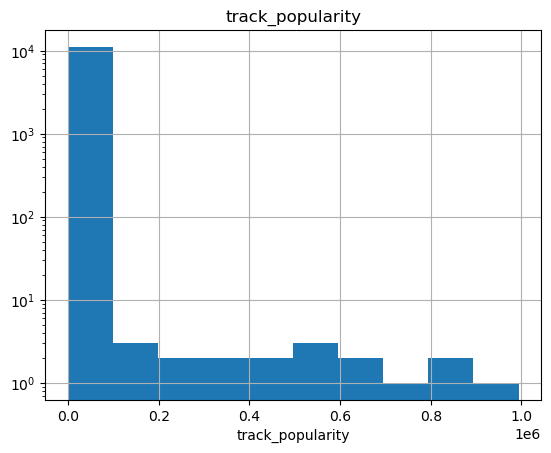

float64


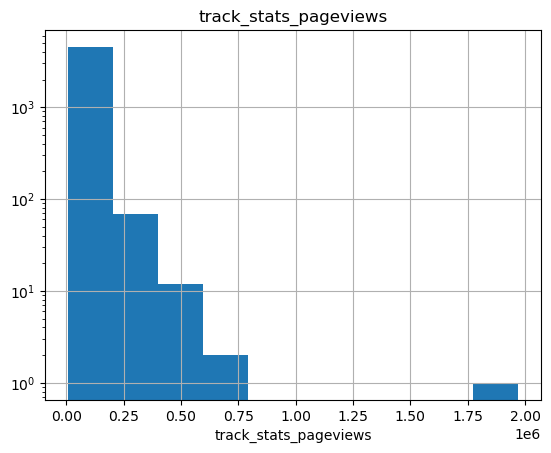

float64


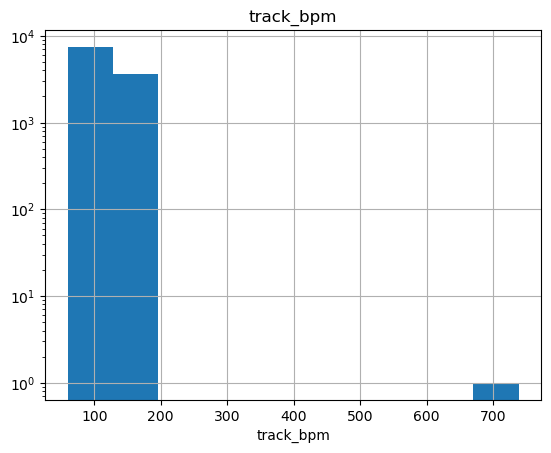

float64


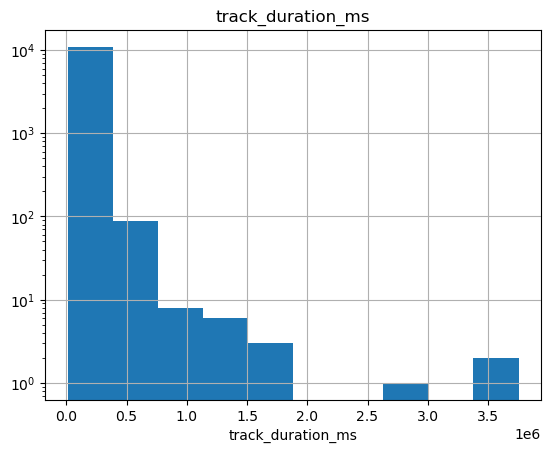

float64


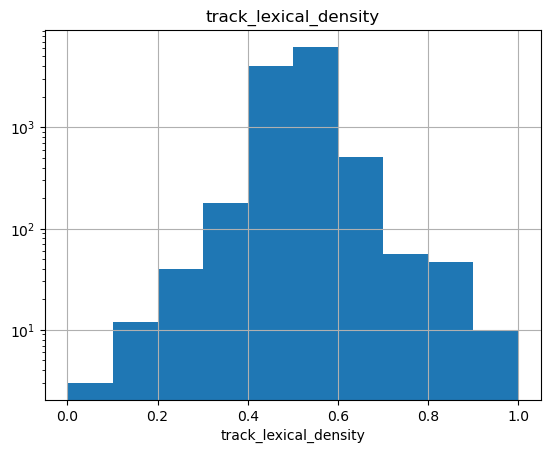

float64


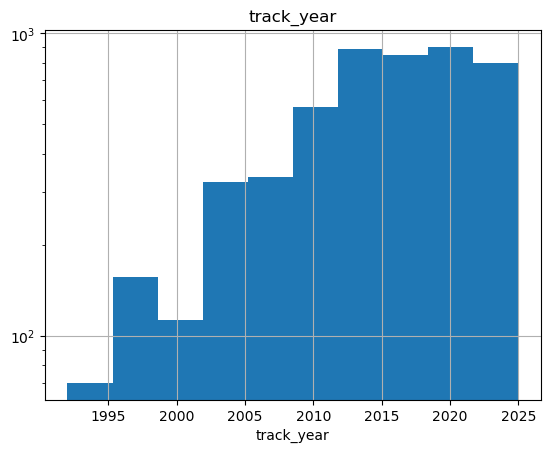

float64


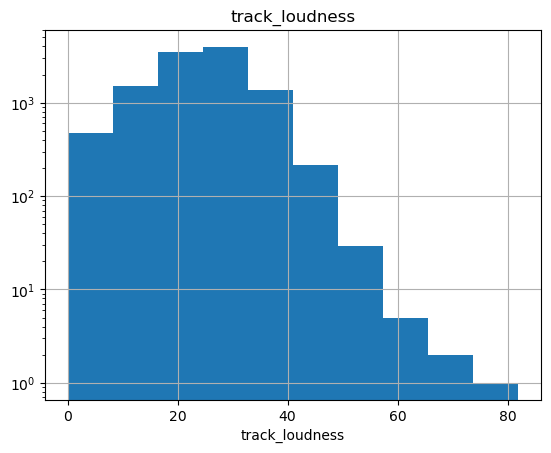

int64


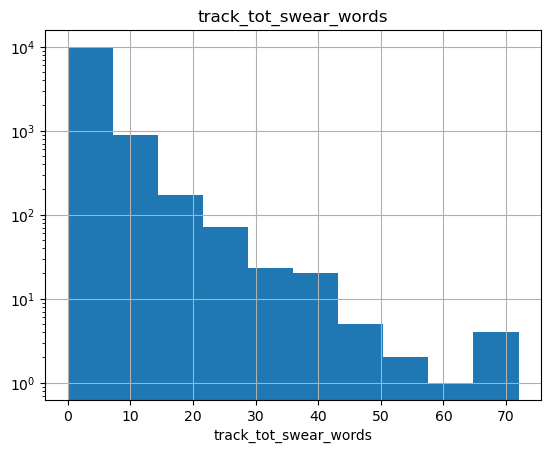

float64


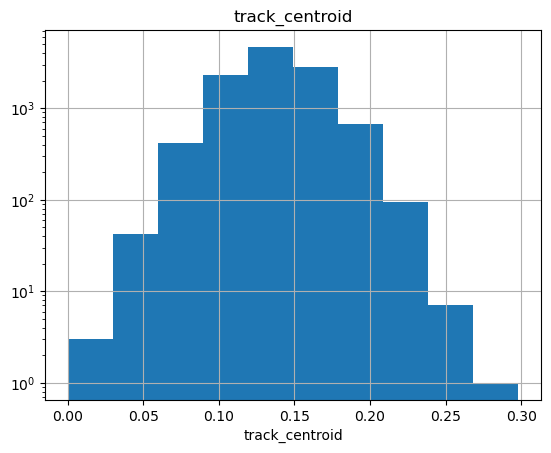

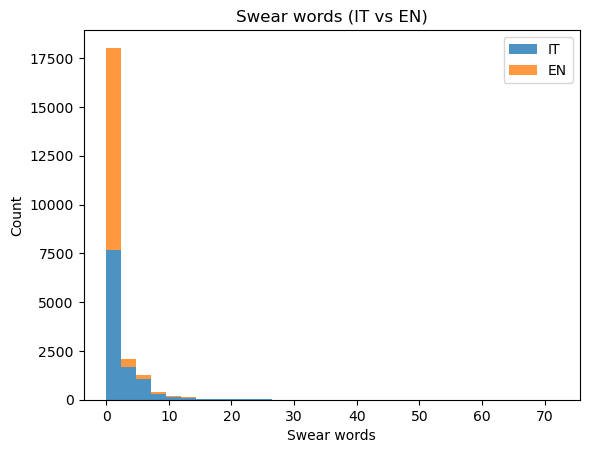

In [189]:
merged["track_tot_swear_words"] = merged["track_swear_IT"] + merged["track_swear_EN"]
for col_name in ["track_popularity", "track_stats_pageviews", "track_bpm", "track_duration_ms", 
                 "track_lexical_density", "track_year", "track_loudness", "track_tot_swear_words",
                 "track_centroid"]:
    print(merged[col_name].dtype)
    merged[col_name] = pd.to_numeric(merged[col_name], errors="coerce")
    plt.figure()
    merged[col_name].hist()
    plt.title(col_name)
    plt.xlabel(col_name)
    plt.yscale('log')
    plt.show()

swear_it = pd.to_numeric(merged["track_swear_IT"], errors="coerce")
swear_en = pd.to_numeric(merged["track_swear_EN"], errors="coerce")
plt.figure()
plt.hist([swear_it, swear_en], bins=30, stacked=True, label=["IT", "EN"], alpha=0.8)
plt.title("Swear words (IT vs EN)")
plt.xlabel("Swear words")
plt.ylabel("Count")
plt.legend()
plt.show()

In [190]:
merged["track_presumed_flatness"] = pd.to_numeric(merged["track_spectral_complexity"], errors="coerce") / (
    pd.to_numeric(merged["track_rolloff"], errors="coerce") - pd.to_numeric(merged["track_centroid"], errors="coerce")
)

merged["track_avg_swear_words"] = merged["track_tot_swear_words"] / merged["track_n_tokens"]


merged["artist_birth_year"] = (
    pd.to_numeric(merged["artist_birth_date"].astype(str).str.slice(0, 4), errors="coerce")
    .astype("Int64")
)

merged["track_artist_age"]= merged["track_year"] - merged["artist_birth_year"]

merged["track_tokens_per_sec"] = merged["track_n_tokens"] / (merged["track_duration_ms"] / 1000)


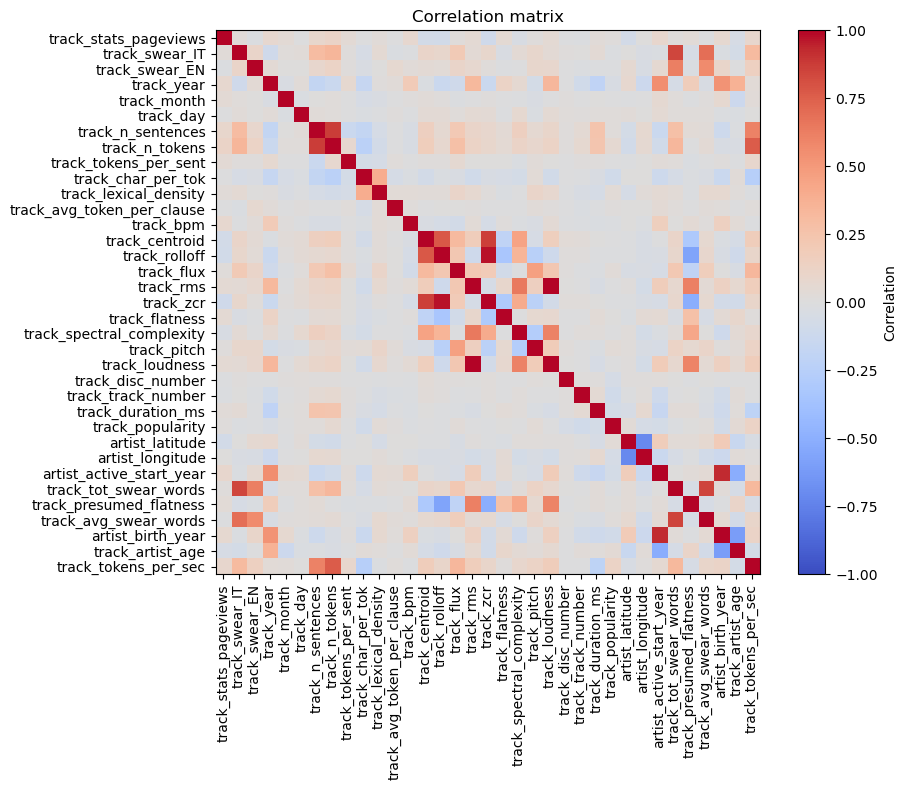

Strongly correlated pairs:
track_rms                  track_loudness               0.995555
track_rolloff              track_zcr                    0.969097
artist_active_start_year   artist_birth_year            0.927140
track_n_sentences          track_n_tokens               0.867736
track_centroid             track_zcr                    0.864452
track_tot_swear_words      track_avg_swear_words        0.850804
track_swear_IT             track_tot_swear_words        0.842228
track_centroid             track_rolloff                0.775643
track_n_tokens             track_tokens_per_sec         0.760372
track_swear_IT             track_avg_swear_words        0.693247
track_rms                  track_spectral_complexity    0.644292
track_swear_EN             track_tot_swear_words        0.623791
track_rms                  track_presumed_flatness      0.616917
track_n_sentences          track_tokens_per_sec         0.609353
track_spectral_complexity  track_loudness               0.60888

In [191]:
# Correlation heatmap for numeric columns
corr = merged.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = corr_pairs.stack().sort_values(ascending=False)
print("Strongly correlated pairs:")
print(strong_pairs[strong_pairs.abs() > 0.5])

Tra rms e loudness teniamo loudness 
tra rolloff, zcr, e centroid teniamo centroid
tra n_sentences e n_token teniamo n_tokens
tra latitude e longitude teniamo latitude
tra swear words IT ed ENG teniamo IT

(1, 1000000.0)

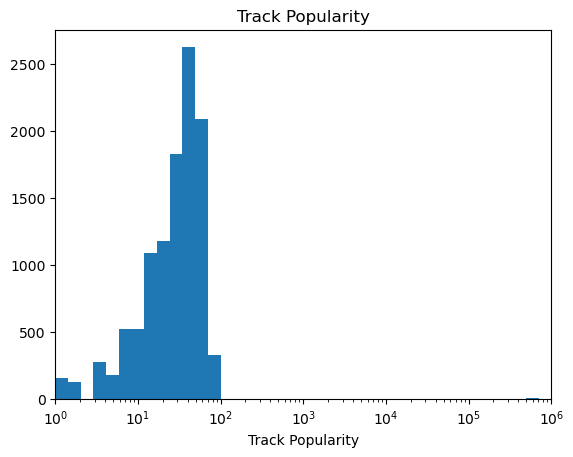

In [192]:
merged['track_popularity'] = pd.to_numeric(merged['track_popularity'], errors="coerce")
pop = merged['track_popularity'].dropna()
pop = pop[pop > 0]  # log bins need positive values

bins = np.logspace(np.log10(1), np.log10(1e6), 40)  # 40 log-width bins

plt.figure('1')
plt.hist(pop, bins=bins)
plt.xscale('log')
plt.title('Track Popularity')
plt.xlabel('Track Popularity')
plt.xlim(1, 1e6)
